# Exploratory Data Analysis — CWRU Bearing Faults

**Goal:** before chasing a fancier model, *understand the signal*. This notebook
answers two questions a data scientist asks first:

1. **Descriptive** — what do healthy vs faulty vibrations actually look like?
2. **Predictive** — which *interpretable* features separate the fault classes, and
   do they agree with the bearing physics?

Along the way this explains **why our CNN already hits ~100%** at a single
operating condition, and motivates the harder cross-load benchmark.

> Run order: `python src/downloader.py` must have populated `data/` first.

In [1]:
import os, sys

# Locate the project root no matter where the kernel's CWD is.
cur = os.path.abspath(os.getcwd())
while cur != os.path.dirname(cur):
    if os.path.exists(os.path.join(cur, "src", "preprocess.py")):
        break
    cur = os.path.dirname(cur)
PROJECT_ROOT = cur
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))
REPORTS = os.path.join(PROJECT_ROOT, "reports"); os.makedirs(REPORTS, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

from downloader import FILES, DATA_DIR, LABEL_NAMES
from preprocess import build_dataset, segment_signal, load_signal, compute_fft, FS, SEGMENT_LENGTH
from features import (build_feature_frame, FEATURE_COLUMNS, envelope_spectrum,
                      characteristic_frequencies, DEFAULT_RPM)

PALETTE = dict(zip(LABEL_NAMES, sns.color_palette("Set2", len(LABEL_NAMES))))
print("Project root:", PROJECT_ROOT)
print("Classes:", LABEL_NAMES)

Project root: /home/williemaize/workspace/projects/predictive-maintenance-pdm
Classes: ['Normal', 'Inner Race', 'Ball', 'Outer Race']


## 1 · Descriptive — what does the raw signal look like?

We load the full Drive-End recording for each health state. Note the **Normal**
recording is ~2× longer, which is why the pipeline balances classes downstream.

In [2]:
signals = {e["fault"]: load_signal(os.path.join(DATA_DIR, f'{e["file_id"]}.mat')) for e in FILES}
pd.DataFrame({"samples": {k: len(v) for k, v in signals.items()},
             "seconds": {k: round(len(v)/FS, 2) for k, v in signals.items()}})

,samples,seconds
Normal,243938,20.33
Inner Race,121265,10.11
Ball,122571,10.21
Outer Race,121991,10.17


### Raw waveforms — you can *see* the fault

Healthy vibration is comparatively smooth and stationary. A bearing defect produces
**periodic impacts** every time a ball strikes the crack — sharp, repeating spikes.

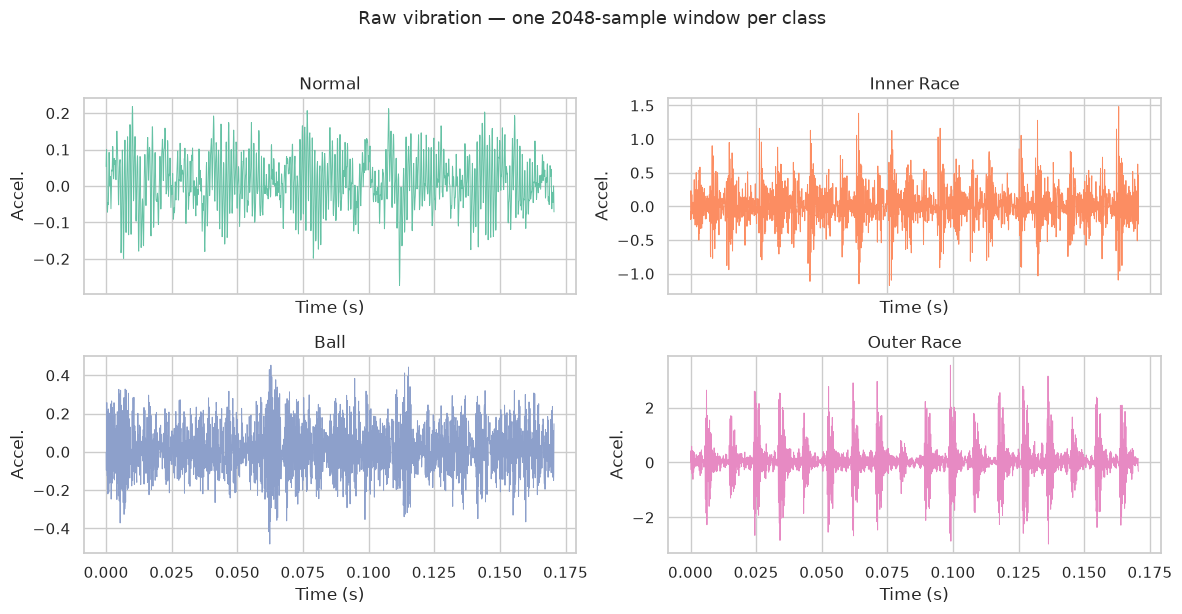

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
for ax, fault in zip(axes.ravel(), LABEL_NAMES):
    seg = signals[fault][:SEGMENT_LENGTH]
    t = np.arange(len(seg)) / FS
    ax.plot(t, seg, lw=0.7, color=PALETTE[fault])
    ax.set_title(fault); ax.set_xlabel("Time (s)"); ax.set_ylabel("Accel.")
fig.suptitle("Raw vibration — one 2048-sample window per class", y=1.02, fontsize=13)
fig.tight_layout(); plt.show()

### Amplitude distributions

Faults inject impulsive transients, which fatten the **tails** of the amplitude
histogram — the visual cue that **kurtosis** (a tail-heaviness statistic) will
turn out to be a strong feature.

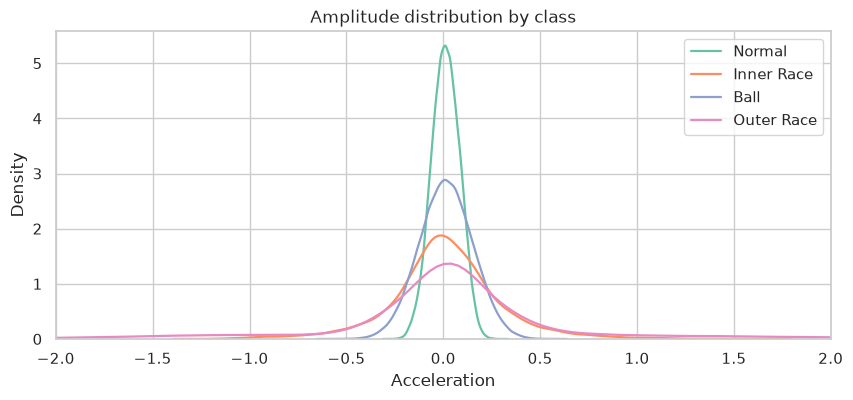

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
for fault in LABEL_NAMES:
    sns.kdeplot(signals[fault][:60000], label=fault, color=PALETTE[fault], lw=1.6, ax=ax)
ax.set_xlim(-2, 2); ax.set_title("Amplitude distribution by class"); ax.set_xlabel("Acceleration")
ax.legend(); plt.show()

### Averaged frequency spectrum (FFT)

Averaging the FFT magnitude over many windows reveals where each fault concentrates
its energy. Faults light up **high-frequency resonance bands** that Normal does not.

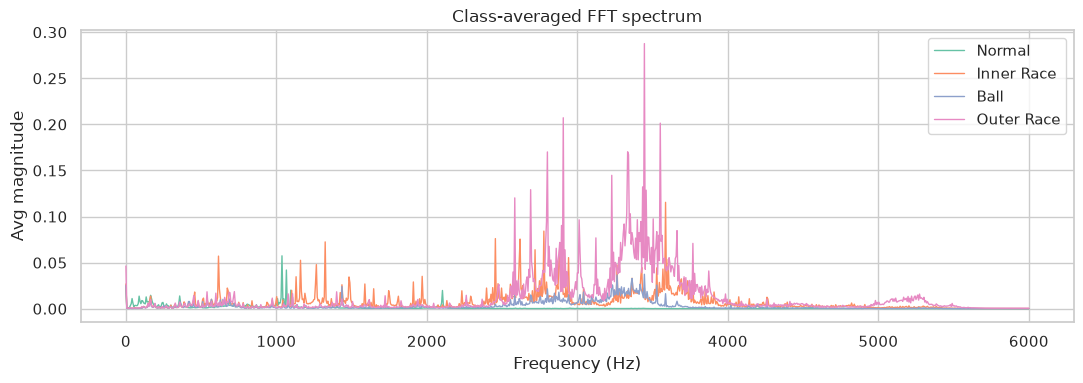

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
for fault, sig in signals.items():
    segs = segment_signal(sig, SEGMENT_LENGTH, 0.5)[:200]
    mags = [compute_fft(s, FS)[1] for s in segs]
    freqs, _ = compute_fft(segs[0], FS)
    ax.plot(freqs, np.mean(mags, axis=0), label=fault, color=PALETTE[fault], lw=1.0)
ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Avg magnitude")
ax.set_title("Class-averaged FFT spectrum"); ax.legend()
fig.tight_layout(); fig.savefig(os.path.join(REPORTS, "eda_avg_fft.png"), dpi=150); plt.show()

## 2 · Engineered features — descriptive statistics that predict

We compute a standard rotating-machinery feature set on every segment (using the
**leakage-free** split so nothing here contaminates a later baseline):

- **Time-domain:** RMS, peak, kurtosis, crest factor, shape/impulse/clearance factors…
- **Envelope-spectrum energy** at the bearing's characteristic defect frequencies.

In [6]:
ds = build_dataset(split_strategy="temporal")
raw_all = np.concatenate([ds.raw_train, ds.raw_val, ds.raw_test])
y_all   = np.concatenate([ds.y_train,  ds.y_val,  ds.y_test])
df = build_feature_frame(raw_all, y_all, LABEL_NAMES)
print(df.shape, "| features:", len(FEATURE_COLUMNS))
df.head()

(436, 22) | features: 20


,mean,std,rms,peak,peak_to_peak,skewness,kurtosis,crest_factor,shape_factor,impulse_factor,...,spec_spread,spec_skew,spec_kurtosis,spec_energy,env_FTF,env_BPFO,env_BSF,env_BPFI,label,fault
0,0.010285,0.072967,0.073688,0.249295,0.496713,-0.147535,-0.069035,3.383105,1.246316,4.216417,...,1033.577353,10.162800,145.308143,11609.303658,4.803294,5.166864,1.009019,7.118816,0,Normal
1,0.010806,0.072344,0.073146,0.247418,0.462918,-0.132286,0.019777,3.382503,1.257596,4.253822,...,1055.437132,10.450165,157.314052,11465.488252,5.318150,6.563768,2.865352,4.111977,0,Normal
2,0.011016,0.071265,0.072112,0.224679,0.428287,-0.083451,-0.205601,3.115698,1.240096,3.863765,...,1053.383823,9.845477,140.675839,11159.952702,7.001565,5.184007,2.088314,1.447195,0,Normal
3,0.011833,0.071696,0.072666,0.208824,0.408052,-0.141133,-0.100709,2.873745,1.252938,3.600624,...,1058.923783,10.688418,163.923668,11367.373342,10.079972,8.121159,3.072988,4.277934,0,Normal
4,0.011567,0.071870,0.072794,0.208824,0.408052,-0.160640,-0.234087,2.868682,1.239291,3.555130,...,1048.305401,9.961387,145.948104,11393.456440,9.227629,12.437328,2.696355,6.173356,0,Normal


In [7]:
# Mean of each feature by class — a compact 'fingerprint' table.
df.groupby("fault")[FEATURE_COLUMNS].mean().round(3).T

fault,Ball,Inner Race,Normal,Outer Race
mean,0.013,0.014,0.012,0.024
std,0.138,0.291,0.072,0.669
rms,0.139,0.292,0.073,0.669
peak,0.493,1.490,0.235,3.274
peak_to_peak,0.941,2.636,0.443,6.317
skewness,-0.009,0.162,-0.038,0.058
kurtosis,-0.039,2.389,-0.237,4.613
crest_factor,3.557,5.110,3.198,4.897
shape_factor,1.252,1.396,1.240,1.649
impulse_factor,4.452,7.133,3.966,8.073


### Which features separate the classes?

Boxplots of a few key features. Watch **kurtosis** and **crest factor**: Normal sits
low (near-Gaussian, non-impulsive) while the faults rise.

/tmp/ipykernel_11251/3862222082.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="fault", y=feat, order=order, palette=PALETTE, ax=ax)
/tmp/ipykernel_11251/3862222082.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="fault", y=feat, order=order, palette=PALETTE, ax=ax)
/tmp/ipykernel_11251/3862222082.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="fault", y=feat, order=order, palette=PALETTE, ax=ax)
/tmp/ipykernel_11251/3862222082.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is 

/tmp/ipykernel_11251/3862222082.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="fault", y=feat, order=order, palette=PALETTE, ax=ax)


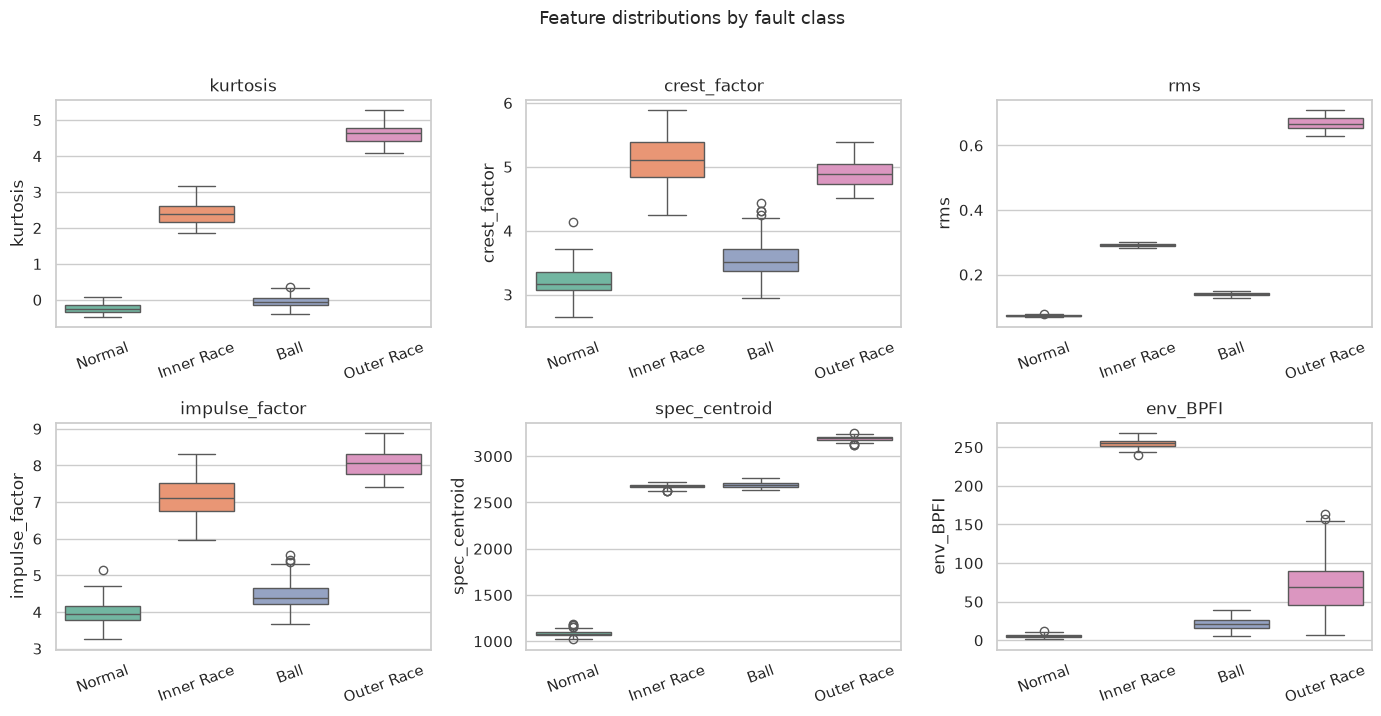

In [8]:
key = ["kurtosis", "crest_factor", "rms", "impulse_factor", "spec_centroid", "env_BPFI"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
order = LABEL_NAMES
for ax, feat in zip(axes.ravel(), key):
    sns.boxplot(data=df, x="fault", y=feat, order=order, palette=PALETTE, ax=ax)
    ax.set_title(feat); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=20)
fig.suptitle("Feature distributions by fault class", y=1.02, fontsize=13)
fig.tight_layout(); plt.show()

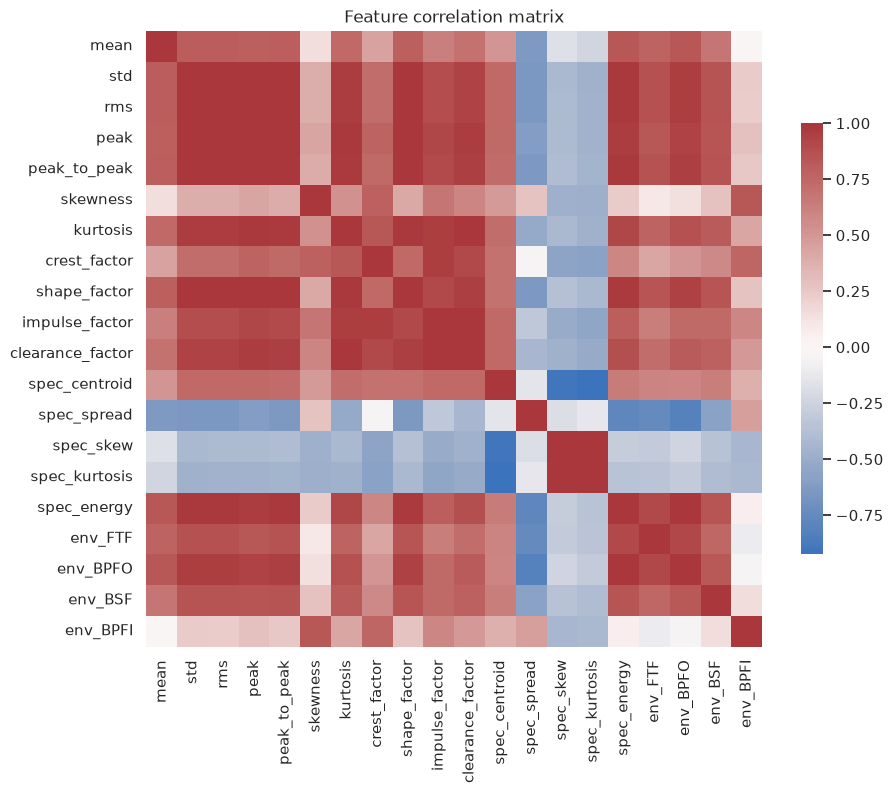

In [9]:
# Feature correlation — spot redundancy among the engineered features.
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[FEATURE_COLUMNS].corr(), cmap="vlag", center=0, square=True,
            cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("Feature correlation matrix"); plt.show()

## 3 · Predictive power

### 3a · Univariate ranking (ANOVA F + mutual information)
How class-discriminative is each feature *on its own*?

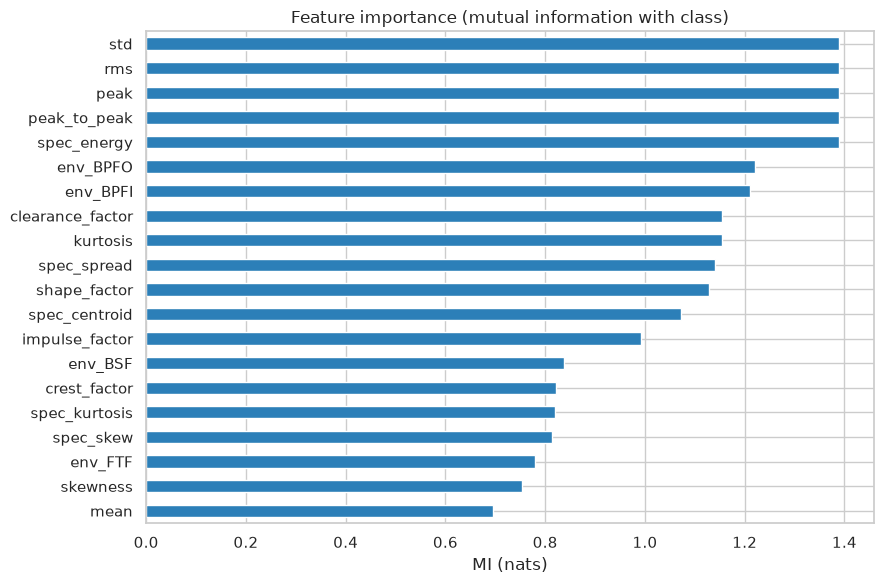

,ANOVA_F,mutual_info
std,80233.919,1.390
rms,80299.557,1.390
peak,27445.682,1.390
peak_to_peak,44184.999,1.390
spec_energy,29866.343,1.390
env_BPFO,69552.092,1.222
env_BPFI,4461.373,1.210
clearance_factor,4186.498,1.155
kurtosis,12625.483,1.154
spec_spread,1605.828,1.140


In [10]:
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.preprocessing import StandardScaler

X = df[FEATURE_COLUMNS].values
y = df["label"].values
Xs = StandardScaler().fit_transform(X)

F, _ = f_classif(Xs, y)
mi = mutual_info_classif(Xs, y, random_state=42)
rank = (pd.DataFrame({"ANOVA_F": F, "mutual_info": mi}, index=FEATURE_COLUMNS)
        .sort_values("mutual_info", ascending=False))

fig, ax = plt.subplots(figsize=(9, 6))
rank["mutual_info"].sort_values().plot.barh(ax=ax, color="#2c7fb8")
ax.set_title("Feature importance (mutual information with class)"); ax.set_xlabel("MI (nats)")
fig.tight_layout(); plt.show()
rank.round(3)

### 3b · A classic-ML baseline (no deep learning)

If a Random Forest on these hand-crafted features already nails it, that **quantifies
how easy the single-condition task is** — and gives interpretable importances. We
train/test on the **leakage-free split**.

RandomForest test accuracy (leakage-free): 1.000


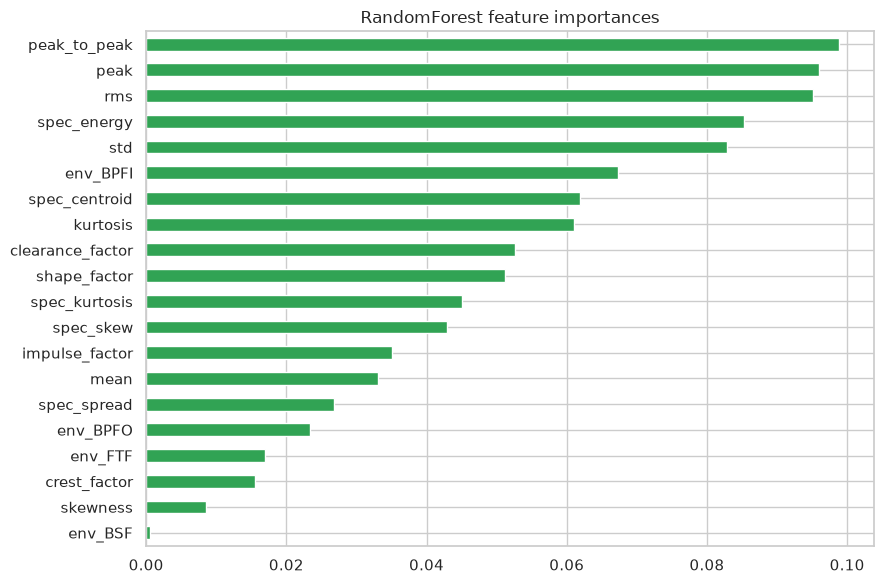

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df_tr = build_feature_frame(ds.raw_train, ds.y_train, LABEL_NAMES)
df_te = build_feature_frame(ds.raw_test,  ds.y_test,  LABEL_NAMES)
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(df_tr[FEATURE_COLUMNS].values, df_tr["label"].values)
pred = rf.predict(df_te[FEATURE_COLUMNS].values)
print(f"RandomForest test accuracy (leakage-free): {accuracy_score(df_te['label'], pred):.3f}")

imp = pd.Series(rf.feature_importances_, index=FEATURE_COLUMNS).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
imp.plot.barh(ax=ax, color="#31a354"); ax.set_title("RandomForest feature importances")
fig.tight_layout(); plt.show()

### 3c · t-SNE — why the CNN gets ~100%

Projecting the engineered-feature space to 2-D. If the classes form **clean,
well-separated clusters**, then *any* competent model will score near-perfectly —
the difficulty isn't the model, it's that this benchmark is easy.

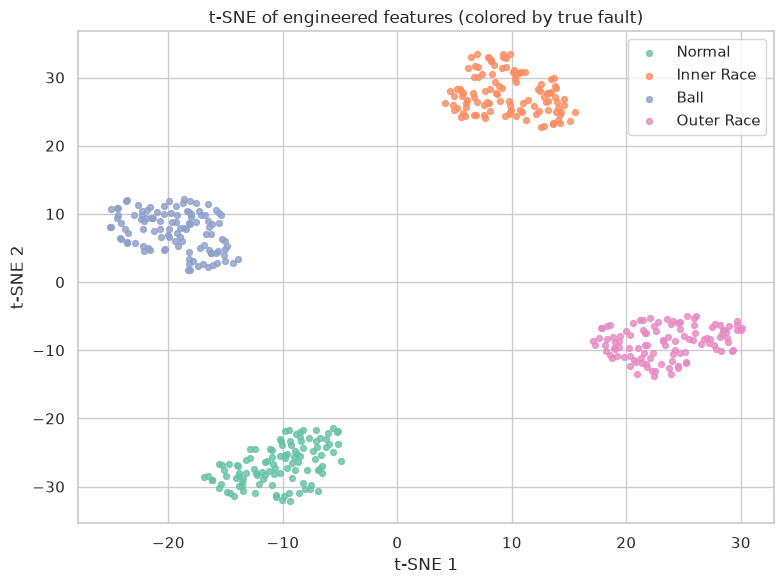

In [12]:
from sklearn.manifold import TSNE
emb = TSNE(n_components=2, random_state=42, perplexity=30, init="pca",
           learning_rate="auto").fit_transform(Xs)
fig, ax = plt.subplots(figsize=(8, 6))
for fault in LABEL_NAMES:
    m = df["fault"].values == fault
    ax.scatter(emb[m, 0], emb[m, 1], s=18, label=fault, color=PALETTE[fault], alpha=.8)
ax.set_title("t-SNE of engineered features (colored by true fault)")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2"); ax.legend()
fig.tight_layout(); fig.savefig(os.path.join(REPORTS, "eda_tsne.png"), dpi=150); plt.show()

## 4 · Does the data agree with the *physics*? (Envelope analysis)

The expert move. The CWRU drive-end bearing is an **SKF 6205**, whose defect
frequencies are fixed multiples of shaft speed. **Envelope (demodulation) analysis**
extracts the impact-repetition rate; the peak should land on the frequency that
matches the *actual* fault — strong evidence the model is learning real physics,
not an artifact.

Shaft speed: 1797 rpm  ->  fr = 29.95 Hz
{'FTF': 11.9, 'BPFO': 107.4, 'BSF': 141.2, 'BPFI': 162.2} (Hz)


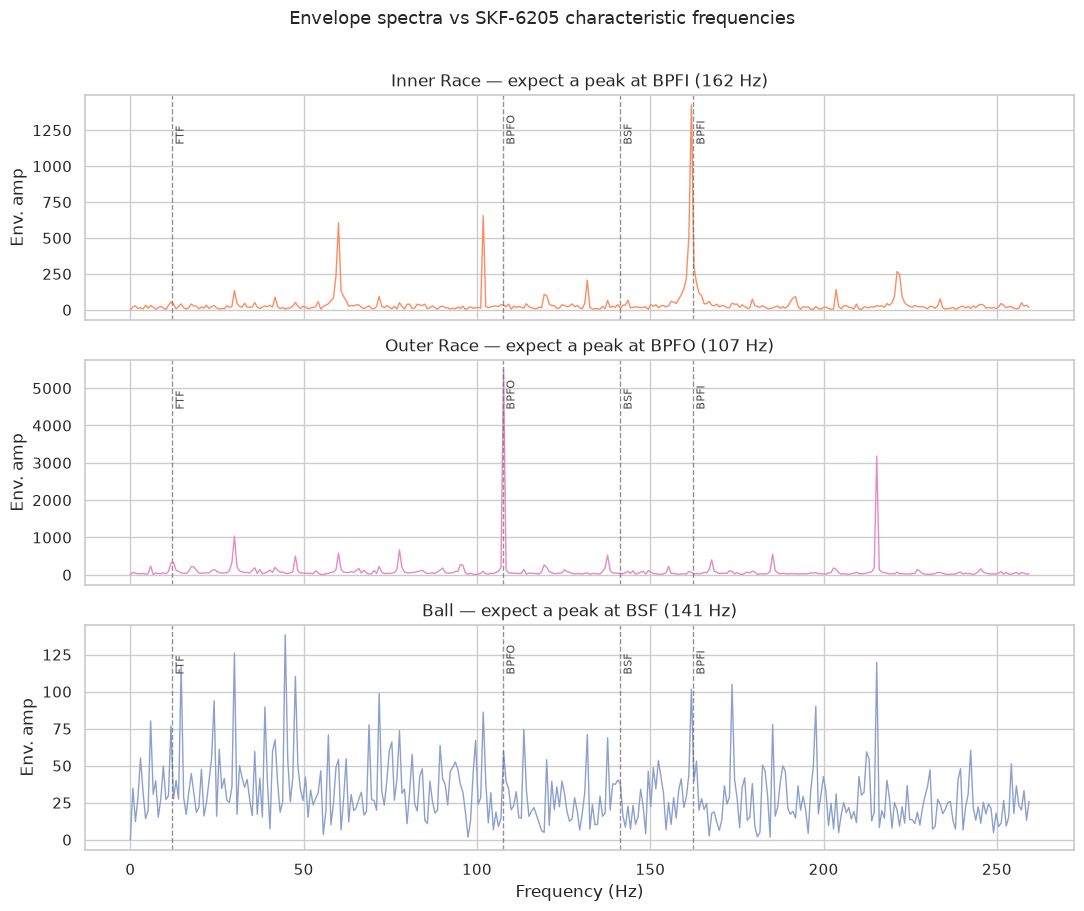

In [13]:
char = characteristic_frequencies(DEFAULT_RPM)
print("Shaft speed:", DEFAULT_RPM, "rpm  ->  fr =", round(DEFAULT_RPM/60, 2), "Hz")
print({k: round(v, 1) for k, v in char.items()}, "(Hz)")

expect = {"Inner Race": "BPFI", "Outer Race": "BPFO", "Ball": "BSF"}
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for ax, (fault, target) in zip(axes, expect.items()):
    f, mag = envelope_spectrum(signals[fault][:16384], FS)
    sel = f <= 260
    ax.plot(f[sel], mag[sel], color=PALETTE[fault], lw=1.0)
    for name, f0 in char.items():
        ax.axvline(f0, ls="--", lw=1, color="0.4", alpha=.7)
        ax.text(f0+1, ax.get_ylim()[1]*0.78, name, fontsize=8, rotation=90, color="0.3")
    ax.set_title(f"{fault} — expect a peak at {target} ({char[target]:.0f} Hz)")
    ax.set_ylabel("Env. amp")
axes[-1].set_xlabel("Frequency (Hz)")
fig.suptitle("Envelope spectra vs SKF-6205 characteristic frequencies", y=1.01, fontsize=13)
fig.tight_layout(); fig.savefig(os.path.join(REPORTS, "eda_envelope.png"), dpi=150); plt.show()

## 5 · Takeaways

- **Descriptive:** faults are *impulsive* — visible as periodic spikes, fat-tailed
  amplitude distributions, and extra high-frequency energy.
- **Predictive:** simple, interpretable features (**kurtosis, crest factor, impulse
  factor**, envelope-band energy) cleanly separate the classes. A RandomForest on
  these alone is near-perfect.
- **Why the CNN hits ~100%:** the t-SNE shows the classes are *trivially separable*
  at this single operating condition — so a high score reflects an **easy benchmark**,
  not a finished product.
- **Physics check:** envelope spectra peak at the SKF-6205 defect frequencies that
  match each fault — the signal carries genuine, explainable diagnostic content.

➡️ **Next:** the genuinely hard test is **cross-load generalization** (train on some
motor loads, test on an unseen load) — Phase 2.